In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
dataset_path = "./dataset"

dataset = datasets.ImageFolder(root=dataset_path, transform=image_transforms)
len(dataset)

2300

In [5]:
2300*0.75

1725.0

In [6]:
class_names = dataset.classes
class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [7]:
num_classes = len(dataset.classes)
num_classes

6

In [8]:
train_size=int(0.75*len(dataset))
val_size=len(dataset)-train_size

In [9]:
from torch.utils.data import random_split

train_dataset,val_dataset=random_split(dataset,[train_size,val_size])

In [10]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32,shuffle=True)

In [11]:
for image, labels in train_loader:
    print(image.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [13]:
labels[1]

tensor(4)

In [14]:
image[1].shape

torch.Size([3, 224, 224])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..1.6813945].


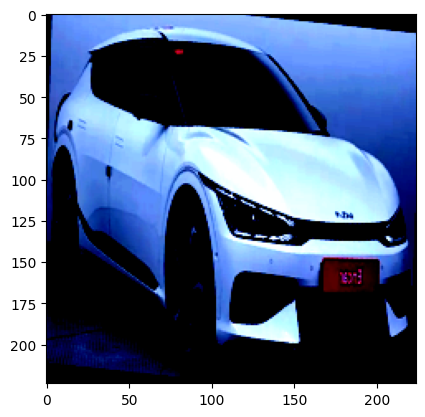

In [17]:
plt.imshow(image[0].permute(1,2,0))
plt.show()

### Model 1

In [32]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()  # Added () after super
        self.network = nn.Sequential(  # Capitalized 'S' in Sequential
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        return self.network(x)

In [20]:
image.size(0)

32

In [21]:
len(train_loader.dataset)

1725

In [33]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
                
            print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")
            
    end = time.time()
    print(f"Execution time: {end - start} seconds")     
    
    return all_labels, all_predictions

In [34]:
# Instantiate the model, loss function, and optimizer
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.80
Batch: 20, Epoch: 1, Loss: 1.79
Batch: 30, Epoch: 1, Loss: 1.79
Batch: 40, Epoch: 1, Loss: 1.79
Batch: 50, Epoch: 1, Loss: 1.79
Epoch [1/10], Avg Loss: 1.9994
*** Validation Accuracy: 21.22% ***
Batch: 10, Epoch: 2, Loss: 1.78
Batch: 20, Epoch: 2, Loss: 1.80
Batch: 30, Epoch: 2, Loss: 1.76
Batch: 40, Epoch: 2, Loss: 1.74
Batch: 50, Epoch: 2, Loss: 1.42
Epoch [2/10], Avg Loss: 1.7127
*** Validation Accuracy: 37.74% ***
Batch: 10, Epoch: 3, Loss: 1.54
Batch: 20, Epoch: 3, Loss: 1.35
Batch: 30, Epoch: 3, Loss: 1.53
Batch: 40, Epoch: 3, Loss: 1.36
Batch: 50, Epoch: 3, Loss: 1.40
Epoch [3/10], Avg Loss: 1.4359
*** Validation Accuracy: 43.13% ***
Batch: 10, Epoch: 4, Loss: 1.23
Batch: 20, Epoch: 4, Loss: 1.07
Batch: 30, Epoch: 4, Loss: 1.22
Batch: 40, Epoch: 4, Loss: 1.32
Batch: 50, Epoch: 4, Loss: 1.01
Epoch [4/10], Avg Loss: 1.2675
*** Validation Accuracy: 47.13% ***
Batch: 10, Epoch: 5, Loss: 1.35
Batch: 20, Epoch: 5, Loss: 1.06
Batch: 30, Epoch: 5, Loss: 1

### CNN with Regularization

In [35]:
class CarClassifierCNNWithRegularization(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), # (16, 224, 224) 
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (16, 112, 112),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (32, 56, 56)           
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # (64, 28, 28),
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.network(x)
        return x

In [36]:
model = CarClassifierCNNWithRegularization(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

all_labels, all_predictions = train_model(model, criterion, optimizer,  epochs=10)

Batch: 10, Epoch: 1, Loss: 12.48
Batch: 20, Epoch: 1, Loss: 6.95
Batch: 30, Epoch: 1, Loss: 5.85
Batch: 40, Epoch: 1, Loss: 2.56
Batch: 50, Epoch: 1, Loss: 1.62
Epoch [1/10], Avg Loss: 7.3502
*** Validation Accuracy: 41.74% ***
Batch: 10, Epoch: 2, Loss: 1.24
Batch: 20, Epoch: 2, Loss: 1.68
Batch: 30, Epoch: 2, Loss: 1.39
Batch: 40, Epoch: 2, Loss: 1.11
Batch: 50, Epoch: 2, Loss: 1.20
Epoch [2/10], Avg Loss: 1.5298
*** Validation Accuracy: 44.17% ***
Batch: 10, Epoch: 3, Loss: 1.58
Batch: 20, Epoch: 3, Loss: 1.09
Batch: 30, Epoch: 3, Loss: 1.28
Batch: 40, Epoch: 3, Loss: 1.35
Batch: 50, Epoch: 3, Loss: 1.30
Epoch [3/10], Avg Loss: 1.2952
*** Validation Accuracy: 49.39% ***
Batch: 10, Epoch: 4, Loss: 1.37
Batch: 20, Epoch: 4, Loss: 1.23
Batch: 30, Epoch: 4, Loss: 1.21
Batch: 40, Epoch: 4, Loss: 1.20
Batch: 50, Epoch: 4, Loss: 1.19
Epoch [4/10], Avg Loss: 1.1889
*** Validation Accuracy: 51.48% ***
Batch: 10, Epoch: 5, Loss: 1.23
Batch: 20, Epoch: 5, Loss: 1.05
Batch: 30, Epoch: 5, Loss: 

### TL with EfficientNet

In [37]:
model = models.efficientnet_b0(weights='DEFAULT')
model.classifier[1].in_features

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\ayush/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 18.9MB/s]


1280

In [38]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')
        
        for param in self.model.parameters():
            param.requires_grad = False
        
        in_features = self.model.classifier[1].in_features
        
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )
        
    def forward(self, x):
        x = self.model(x)
        return x              

In [39]:
model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.73
Batch: 20, Epoch: 1, Loss: 1.42
Batch: 30, Epoch: 1, Loss: 1.49
Batch: 40, Epoch: 1, Loss: 1.39
Batch: 50, Epoch: 1, Loss: 1.17
Epoch [1/10], Avg Loss: 1.4855
*** Validation Accuracy: 55.48% ***
Batch: 10, Epoch: 2, Loss: 1.11
Batch: 20, Epoch: 2, Loss: 1.03
Batch: 30, Epoch: 2, Loss: 1.25
Batch: 40, Epoch: 2, Loss: 1.03
Batch: 50, Epoch: 2, Loss: 1.17
Epoch [2/10], Avg Loss: 1.1229
*** Validation Accuracy: 58.26% ***
Batch: 10, Epoch: 3, Loss: 1.21
Batch: 20, Epoch: 3, Loss: 1.02
Batch: 30, Epoch: 3, Loss: 1.04
Batch: 40, Epoch: 3, Loss: 0.84
Batch: 50, Epoch: 3, Loss: 0.96
Epoch [3/10], Avg Loss: 1.0002
*** Validation Accuracy: 60.52% ***
Batch: 10, Epoch: 4, Loss: 1.08
Batch: 20, Epoch: 4, Loss: 1.02
Batch: 30, Epoch: 4, Loss: 0.87
Batch: 40, Epoch: 4, Loss: 0.91
Batch: 50, Epoch: 4, Loss: 1.18
Epoch [4/10], Avg Loss: 0.9496
*** Validation Accuracy: 61.74% ***
Batch: 10, Epoch: 5, Loss: 1.19
Batch: 20, Epoch: 5, Loss: 0.80
Batch: 30, Epoch: 5, Loss: 0

### With ResNet

In [41]:
# Load the pre-trained ResNet model
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True            
            
        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [42]:
model = CarClassifierResNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\ayush/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 28.6MB/s]


Batch: 10, Epoch: 1, Loss: 0.94
Batch: 20, Epoch: 1, Loss: 0.61
Batch: 30, Epoch: 1, Loss: 0.48
Batch: 40, Epoch: 1, Loss: 0.59
Batch: 50, Epoch: 1, Loss: 0.69
Epoch [1/10], Avg Loss: 0.8608
*** Validation Accuracy: 69.74% ***
Batch: 10, Epoch: 2, Loss: 0.39
Batch: 20, Epoch: 2, Loss: 0.39
Batch: 30, Epoch: 2, Loss: 0.36
Batch: 40, Epoch: 2, Loss: 0.67
Batch: 50, Epoch: 2, Loss: 0.33
Epoch [2/10], Avg Loss: 0.5123
*** Validation Accuracy: 73.57% ***
Batch: 10, Epoch: 3, Loss: 0.25
Batch: 20, Epoch: 3, Loss: 0.40
Batch: 30, Epoch: 3, Loss: 0.31
Batch: 40, Epoch: 3, Loss: 0.47
Batch: 50, Epoch: 3, Loss: 0.40
Epoch [3/10], Avg Loss: 0.3451
*** Validation Accuracy: 76.87% ***
Batch: 10, Epoch: 4, Loss: 0.05
Batch: 20, Epoch: 4, Loss: 0.65
Batch: 30, Epoch: 4, Loss: 0.16
Batch: 40, Epoch: 4, Loss: 0.13
Batch: 50, Epoch: 4, Loss: 0.17
Epoch [4/10], Avg Loss: 0.2572
*** Validation Accuracy: 77.04% ***
Batch: 10, Epoch: 5, Loss: 0.08
Batch: 20, Epoch: 5, Loss: 0.31
Batch: 30, Epoch: 5, Loss: 0

### model with best parameter

In [43]:
model = CarClassifierResNet(num_classes=num_classes, dropout_rate=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.005)

labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.19
Batch: 20, Epoch: 1, Loss: 0.90
Batch: 30, Epoch: 1, Loss: 0.53
Batch: 40, Epoch: 1, Loss: 0.50
Batch: 50, Epoch: 1, Loss: 0.58
Epoch [1/10], Avg Loss: 0.9047
*** Validation Accuracy: 63.48% ***
Batch: 10, Epoch: 2, Loss: 0.65
Batch: 20, Epoch: 2, Loss: 0.69
Batch: 30, Epoch: 2, Loss: 0.32
Batch: 40, Epoch: 2, Loss: 0.66
Batch: 50, Epoch: 2, Loss: 0.38
Epoch [2/10], Avg Loss: 0.4953
*** Validation Accuracy: 74.26% ***
Batch: 10, Epoch: 3, Loss: 0.25
Batch: 20, Epoch: 3, Loss: 0.30
Batch: 30, Epoch: 3, Loss: 0.41
Batch: 40, Epoch: 3, Loss: 0.29
Batch: 50, Epoch: 3, Loss: 0.11
Epoch [3/10], Avg Loss: 0.3109
*** Validation Accuracy: 77.39% ***
Batch: 10, Epoch: 4, Loss: 0.54
Batch: 20, Epoch: 4, Loss: 0.17
Batch: 30, Epoch: 4, Loss: 0.23
Batch: 40, Epoch: 4, Loss: 0.28
Batch: 50, Epoch: 4, Loss: 0.43
Epoch [4/10], Avg Loss: 0.2724
*** Validation Accuracy: 75.83% ***
Batch: 10, Epoch: 5, Loss: 0.14
Batch: 20, Epoch: 5, Loss: 0.19
Batch: 30, Epoch: 5, Loss: 0

### model evaluation

In [44]:
from sklearn.metrics import classification_report

report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.70      0.80       126
           1       0.72      0.78      0.75       108
           2       0.79      0.95      0.87       122
           3       0.84      0.74      0.79        65
           4       0.70      0.59      0.64        75
           5       0.69      0.86      0.77        79

    accuracy                           0.78       575
   macro avg       0.78      0.77      0.77       575
weighted avg       0.79      0.78      0.78       575



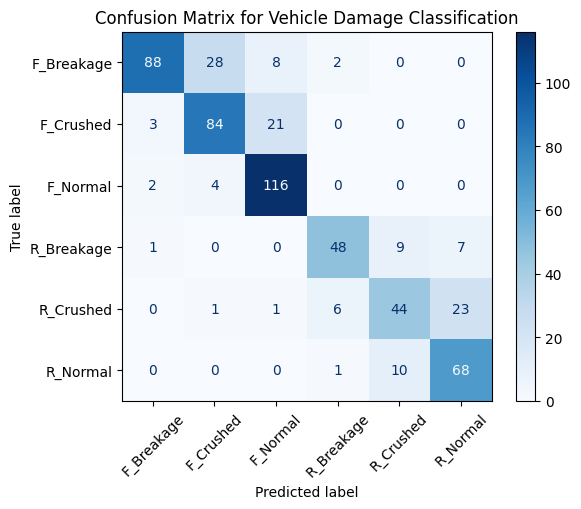

In [45]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

### saving the model

In [46]:
torch.save(model.state_dict(), 'saved_model.pth')